# Failure Trajectories

This notebook studies financial-distress trajectories around primary failure events. It constructs event-time panels, assesses data availability, matches failure firms to never-failure controls, estimates matched trajectories, and produces the main and robustness outputs for RQ1.

**Run order:** run `01_data_cleaning.ipynb` first so `data/processed/merged_df.xlsx` is available.

Fella Bouznad, 30/09/2026 \
MPhil Thesis Business Data Science - Operations Analytics

In [160]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
#globals
ID_COL = 'bvdid'     
YEAR_COL = 'year'
FAIL_COL = 'primary_failure_event'
FDI_COL = 'FDI'
FDI_COMPLETE4_COL = 'FDI_complete4'
ROA_COL = 'roa_clean'
LEV_COL = 'leverage_clean'
LIQ_COL = 'current_ratio_clean'
EQ_COL = 'equity_ratio_clean'
EVENT_WINDOW = range(-5, 1)
FIN_COMPONENTS = [ROA_COL, LEV_COL, LIQ_COL, EQ_COL]
BASELINE_H = -2
MAIN_EVENT_WINDOW = [-2, -1, 0]
N_CONTROLS = 3
MATCH_COVARS = ['FDI_core3']
BALANCE_COVARS = [
    'FDI_core3',
    'size'
]

CORE_DIMENSIONS = [
    'profitability_distress',
    'solvency_distress',
    'liquidity_distress',
]

SECONDARY_DIMENSIONS = [
    'cashflow_distress',
    'operations_distress',
]

TRAJECTORY_VARS = {
    'Profitability': 'profitability_distress',
    'Solvency': 'solvency_distress',
    'Liquidity': 'liquidity_distress',
    'Core FDI': 'FDI_core3',
}

AVAILABILITY_VARS = {
    'Profitability': 'profitability_distress',
    'Solvency': 'solvency_distress',
    'Liquidity': 'liquidity_distress',
    'Core FDI': 'FDI_core3',
    'Cash-flow capacity': 'cashflow_distress',
    'Operating performance': 'operations_distress',
}

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'failure_trajectories'
FIGURE_DIR = RESULTS_DIR / 'figures'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df_path = PROCESSED_DATA_DIR / 'merged_df.xlsx'
matching_path = RESULTS_DIR / 'matched_df.xlsx'
RQ1_OUTPUT = RESULTS_DIR / 'rq1_results.xlsx'

In [ ]:
#import data
df = pd.read_excel(df_path) 

## Event-time analysis

Identify each firm's first primary-failure year, align observations in event time, and summarize which financial-distress dimensions are observable before failure. The availability diagnostics distinguish calendar-window limitations from missing financial information.


In [ ]:
def create_event_panel(df):
    df = df[df[YEAR_COL].between(2010,2015)].copy()
    df = df.drop(columns=['failure_year', 'event_time'], errors='ignore')
    failure_years = (df.loc[df[FAIL_COL].eq(1), [ID_COL, YEAR_COL]]
                        .groupby(ID_COL, as_index=False)[YEAR_COL]
                        .min().rename(columns={YEAR_COL:'failure_year'}))
    n_failed_firms = failure_years[ID_COL].nunique()
    df = df.merge(failure_years, on=ID_COL, how='inner')
    df['event_time']= (df[YEAR_COL]-df['failure_year'])
    event_panel_window = df[df['event_time'].isin(EVENT_WINDOW)].copy()
    failures_by_year = (failure_years
                        .groupby('failure_year')[ID_COL].nunique()
                        .reindex(range(2010,2016), fill_value=0)
                        .rename('Primary-failure firms')
                        .reset_index())
    return event_panel_window, n_failed_firms, failures_by_year, failure_years

def create_availability(event_panel_window, n_failed_firms):
    variables = {
            'Any firm-year observed': None,
            'Profitability': 'profitability_distress',
            'Solvency': 'solvency_distress',
            'Liquidity': 'liquidity_distress',
            'Cash-flow capacity': 'cashflow_distress',
            'Operating performance': 'operations_distress',
            'FDI benchmark 4D': 'FDI_benchmark_4d',
            'FDI benchmark 5D': 'FDI_benchmark_5d',
    }

    rows = []

    for h in EVENT_WINDOW:
        temp = event_panel_window[event_panel_window['event_time'].eq(h)]
        row = {
            'Event time': h,
            'Calendar observations': temp[ID_COL].nunique(),
        }
        for label, variable in variables.items():
            if variable is None:
                count = temp[ID_COL].nunique()
            else:
                count = temp.loc[temp[variable].notna(), ID_COL].nunique()
            row[label] = count
        row['Complete 5D vector'] = temp.loc[temp['financial_vector_complete_5d'].eq(1), ID_COL].nunique()
        rows.append(row)
    
    availability_table = pd.DataFrame(rows)
    availability_table = availability_table.sort_values('Event time').reset_index(drop=True)
    availability_pct = availability_table.copy()
    count_cols = [col for col in availability_pct.columns if col != 'Event time']

    for col in count_cols:
        availability_pct[col] = (100 * availability_pct[col] / n_failed_firms).round(1) 
    
    return availability_table, availability_pct

def observed_availability(failure_years, event_panel_window):
    variables = {
        'Profitability': 'profitability_distress',
        'Solvency': 'solvency_distress',
        'Liquidity': 'liquidity_distress',
        'Cash-flow capacity': 'cashflow_distress',
        'Operating performance': 'operations_distress',
        'FDI benchmark 4D': 'FDI_benchmark_4d',
        'FDI benchmark 5D': 'FDI_benchmark_5d',
    }
    adjusted_rows = []

    for h in EVENT_WINDOW:
        eligible_ids = failure_years.loc[failure_years['failure_year'] + h >= 2010, ID_COL]
        n_eligible = eligible_ids.nunique()
        temp = event_panel_window.loc[event_panel_window['event_time'].eq(h)]
        row = {
            'Event time': h,
            'Eligible failure firms': n_eligible,
        }

        for label, variable in variables.items():
            n_available = temp.loc[temp[variable].notna(), ID_COL].nunique()
            row[f'{label} available'] = n_available
            row[f'{label} (%)'] = (round(100 * n_available / n_eligible,1) if n_eligible > 0 else np.nan)

        n_complete5 = temp.loc[temp['financial_vector_complete_5d'].eq(1), ID_COL].nunique()
        row['Complete 5D vector available'] = n_complete5
        row['Complete 5D vector (%)'] = (
                    round(
                        100 * n_complete5 / n_eligible,
                        1
                    )
                    if n_eligible > 0
                    else np.nan
                )

        adjusted_rows.append(row)
        adjusted_availability = pd.DataFrame(adjusted_rows)
    return adjusted_availability

def create_joint_availability(event_panel_window):

    rows = []

    for h in EVENT_WINDOW:

        temp = event_panel_window.loc[
            event_panel_window['event_time'].eq(h)
        ].copy()

        n_obs = temp[ID_COL].nunique()

        core_n = temp[CORE_DIMENSIONS].notna().sum(axis=1)
        all_dimensions = CORE_DIMENSIONS + SECONDARY_DIMENSIONS
        five_n = temp[all_dimensions].notna().sum(axis=1)

        row = {
            'Event time': h,
            'Firm-years observed': n_obs,

            'All 3 core dimensions': temp.loc[
                core_n.eq(3),
                ID_COL
            ].nunique(),

            'At least 2 of 3 core dimensions': temp.loc[
                core_n.ge(2),
                ID_COL
            ].nunique(),

            'At least 1 core dimension': temp.loc[
                core_n.ge(1),
                ID_COL
            ].nunique(),

            'All 5 dimensions': temp.loc[
                five_n.eq(5),
                ID_COL
            ].nunique(),

            'Core 3D + size': temp.loc[
                core_n.eq(3) & temp['size'].notna(),
                ID_COL
            ].nunique(),

            'At least 2 core + size': temp.loc[
                core_n.ge(2) & temp['size'].notna(),
                ID_COL
            ].nunique(),
        }

        rows.append(row)

    return pd.DataFrame(rows)


In [ ]:
analysis_df = df.copy()
event_panel_window, n_failed_firms, failures_by_year, failure_years = create_event_panel(analysis_df)
availability_table, availability_pct = create_availability(event_panel_window, n_failed_firms)
adjusted_availability = observed_availability(failure_years, event_panel_window)
joint_availability = create_joint_availability(event_panel_window)

print(f'event panel window: {event_panel_window}')
print(f'Number of failed firms: {n_failed_firms}')
display(failures_by_year)
display(availability_table)
display(availability_pct)
display(adjusted_availability)
display(joint_availability)

event panel window:           bvdid  year             unique         AF_PTNR_ID_C  \
0    NL02041383  2012  NL02041383 - 2012  TB_AF_215 - TB03474   
4    NL04006089  2010  NL04006089 - 2010                  NaN   
5    NL04006089  2011                NaN                  NaN   
6    NL04006089  2012  NL04006089 - 2012                  NaN   
7    NL04006089  2013  NL04006089 - 2013  TB_AF_283 - TB01943   
..          ...   ...                ...                  ...   
406  NL56569351  2015  NL56569351 - 2015                  NaN   
407  NL59143932  2015  NL59143932 - 2015   TB_AF_68 - TB06184   
408  NL59431679  2011                NaN                  NaN   
409  NL59431679  2012                NaN                  NaN   
410  NL59431679  2013  NL59431679 - 2013                  NaN   

                         company_name  PIE_entity  PTNR_Audited_PIE  \
0           AXENT_NabestaandenZorg_NV         1.0               1.0   
4             NV_Waterbedrijf_Drenthe         0.0        

,Event time,Firm-years observed,All 3 core dimensions,At least 2 of 3 core dimensions,At least 1 core dimension,All 5 dimensions,Core 3D + size,At least 2 core + size
0,-5,4,0,0,0,0,0,0
1,-4,16,6,7,7,0,5,5
2,-3,34,15,17,17,0,10,10
3,-2,41,22,26,26,2,14,14
4,-1,57,28,32,32,2,17,19
5,0,98,36,41,41,3,36,41


## Matched comparison design

Construct the core three-dimensional FDI and match failure firms to never-failure controls at the pre-failure baseline. Matching diagnostics summarize covariate balance and the composition of the matched event-time panel before trajectory estimation.

In [ ]:
def construct_core_fdi(df):
    df = df.copy()
    core_dimensions = [
        'profitability_distress',
        'solvency_distress',
        'liquidity_distress',
    ]
    df['core_n_dimensions'] = (df[core_dimensions].notna().sum(axis=1))
    df['FDI_core3'] = (df[core_dimensions].mean(axis=1).where(df['core_n_dimensions'].ge(2)))
    df['FDI_core3_strict'] = (df[core_dimensions].mean(axis=1).where(df['core_n_dimensions'].eq(3)))
    return df

def create_broad_industry(df):
    df = df.copy()
    sbi = (df['sbi_kvk_1'].astype('string').str.extract(r'(\d+)', expand=False))
    df['industry_2d'] = sbi.str[:2]
    return df

def prepare_matching_sample(df, baseline_h=-2, match_covars= None):
    if match_covars is None:
        match_covars = ['FDI_core3']

    df = df.copy()
    df = df.drop(columns=['failure_year', 'event_time','ever_primary_failure_calc',],errors='ignore')
    df = df.loc[df[YEAR_COL].between(2010, 2015)].copy()
    failure_years = (df.loc[df[FAIL_COL].eq(1),[ID_COL, YEAR_COL]].groupby(ID_COL, as_index=False)[YEAR_COL].min().rename(columns={YEAR_COL: 'failure_year'}))
    ever_failure = (df.groupby(ID_COL)[FAIL_COL].max().rename('ever_primary_failure_calc'))
    df = df.merge(ever_failure,on=ID_COL,how='left')
    treated = df.merge(failure_years,on=ID_COL,how='inner')
    treated['baseline_year'] = (treated['failure_year'] + baseline_h)
    treated_baseline = (treated.loc[treated[YEAR_COL].eq(treated['baseline_year'])].copy())
    treated_baseline = (treated_baseline.dropna(subset=match_covars))
    controls = (df.loc[df['ever_primary_failure_calc'].eq(0)].copy())

    return (treated_baseline, controls, failure_years)

def match_failure_firms(treated_baseline, control_pool, n_controls=3, match_covars=None, industry_col='industry_2d'):
    if match_covars is None:
        match_covars = ['FDI_core3']
    matches = []

    for _, treated in treated_baseline.iterrows():
        treated_id = treated[ID_COL]
        failure_year = treated['failure_year']
        baseline_year = treated['baseline_year']
        candidates = control_pool.loc[control_pool[YEAR_COL].eq(baseline_year)].copy()
        candidates = candidates.dropna(subset=match_covars)
        if len(candidates) == 0:
            continue

        treated_industry = treated[industry_col]
        same_industry = candidates.loc[candidates[industry_col].eq(treated_industry)].copy()

        if len(same_industry) >= 1:
            candidate_pool = same_industry
            match_scope = 'same_industry'
        else:
            candidate_pool = candidates
            match_scope = 'year_only'

        distances = np.zeros(len(candidate_pool))

        for covar in match_covars:
            sd = candidate_pool[covar].std()
            if pd.isna(sd) or sd == 0:
                sd = 1.0
            distances += ((candidate_pool[covar] - treated[covar]) / sd) ** 2

        candidate_pool = candidate_pool.copy()
        candidate_pool['match_distance'] = np.sqrt(distances)
        selected = (candidate_pool.sort_values('match_distance').head(n_controls))

        for _, control in selected.iterrows():
            row = {
                'match_set_id': treated_id,
                'treated_id': treated_id,
                'control_id': control[ID_COL],
                'failure_year': failure_year,
                'baseline_year': baseline_year,
                'treated_industry': treated_industry,
                'control_industry': control[industry_col],
                'match_scope': match_scope,
                'match_distance':
                    control['match_distance'],
            }

            store_covars = list(dict.fromkeys(match_covars + BALANCE_COVARS))
            for covar in store_covars:
                if (covar in treated.index and covar in control.index):
                    row[f'treated_{covar}'] = (treated[covar])
                    row[f'control_{covar}'] = (control[covar])

            '''for covar in match_covars:
                row[f'treated_{covar}'] = (treated[covar])
                row[f'control_{covar}'] = (control[covar])'''

            matches.append(row)

    matches = pd.DataFrame(matches)
    return matches

def summarize_matching(matches):
    if len(matches) == 0:
        print('No matches found.')
        return

    n_treated = matches['treated_id'].nunique()
    n_controls = matches['control_id'].nunique()
    controls_per_treated = (matches.groupby('treated_id')['control_id'].nunique())
    print('Matched failure firms:', n_treated)
    print('Unique control firms:', n_controls)
    print('Mean controls per failure firm:', round(controls_per_treated.mean(), 2))
    print('Median match distance:', round(matches['match_distance'].median(), 3))
    print('\nMatching scope:')
    print(matches['match_scope'].value_counts())

def matching_balance_table(matches, covariates):
    results = []

    if matches.empty:
        return pd.DataFrame()
    
    for covar in covariates:
        treated_col = f'treated_{covar}'
        control_col = f'control_{covar}'
        if (treated_col not in matches.columns or control_col not in matches.columns):
            continue

        temp = (matches[['match_set_id', 'treated_id', 'control_id', treated_col, control_col]].copy())
        temp = temp.loc[temp[treated_col].notna() & temp[control_col].notna()].copy()
        if temp.empty:
            continue
        n_controls = (temp.groupby('match_set_id')['control_id'].transform('nunique'))
        temp['weight'] = (1 / n_controls)

        treated_unique = (temp.drop_duplicates('match_set_id'))
        treated_values = (treated_unique[treated_col].astype(float))
        control_values = (temp[control_col].astype(float))
        control_weights = (temp['weight'])
        treated_mean = (treated_values.mean())
        control_mean = np.average(control_values, weights=control_weights)
        treated_var = (treated_values.var(ddof=1))
        control_var = np.average((control_values - control_mean) ** 2, weights=control_weights)
        pooled_sd = np.sqrt((treated_var + control_var) / 2)
        smd = ((treated_mean - control_mean) / pooled_sd if pooled_sd > 0 else np.nan)

        results.append({
            'Variable': covar,
            'Matched sets': treated_unique['match_set_id'].nunique(),
            'Failure mean': treated_mean,
            'Control mean': control_mean,
            'Standardized mean difference': smd,
        })

    return pd.DataFrame(results)

def build_matched_event_panel(df, matches, event_window=(-2, -1, 0)):
    matched_rows = []
    control_counts = (matches.groupby('match_set_id')['control_id'].nunique().to_dict())
    treated_info = (matches[['match_set_id','treated_id','failure_year',]].drop_duplicates())

    for _, match in treated_info.iterrows():
        firm = df.loc[df[ID_COL].eq(match['treated_id'])].copy()
        firm['match_set_id'] = (match['match_set_id'])
        firm['group'] = 'Primary failure'
        firm['pseudo_failure_year'] = (match['failure_year'])
        firm['event_time'] = (firm[YEAR_COL]- firm['pseudo_failure_year'])
        firm['match_weight'] = 1.0
        firm = firm.loc[firm['event_time'].isin(event_window)]
        matched_rows.append(firm)

    for _, match in matches.iterrows():
        firm = df.loc[df[ID_COL].eq(match['control_id'])].copy()
        firm['match_set_id'] = (match['match_set_id'])
        firm['group'] = 'Matched control'
        firm['pseudo_failure_year'] = (match['failure_year'])
        firm['event_time'] = (firm[YEAR_COL] - firm['pseudo_failure_year'])
        firm['match_weight'] = (1 / control_counts[match['match_set_id']])
        firm = firm.loc[firm['event_time'].isin(event_window)]
        matched_rows.append(firm)

    if len(matched_rows) == 0:
        return pd.DataFrame()

    matched_panel = pd.concat(matched_rows, ignore_index=True)

    return matched_panel

def reweight_matched_event_panel(matched_event_panel):
    panel = matched_event_panel.copy()
    panel['analysis_weight'] = np.nan
    treated_mask = panel['group'].eq('Primary failure')
    panel.loc[treated_mask, 'analysis_weight'] = 1.0
    control_mask = panel['group'].eq('Matched control')
    n_controls_present = (panel.loc[control_mask].groupby(['match_set_id', 'event_time'])[ID_COL] .transform('nunique'))
    panel.loc[control_mask, 'analysis_weight'] = 1 / n_controls_present

    return panel

In [ ]:
analysis_df = df.copy()
analysis_df = construct_core_fdi(analysis_df)
analysis_df = create_broad_industry(analysis_df)
treated_baseline, control_pool, failure_years = (prepare_matching_sample(analysis_df,baseline_h=BASELINE_H))
matches = match_failure_firms(treated_baseline,control_pool, n_controls=N_CONTROLS, match_covars=MATCH_COVARS)
summarize_matching(matches)
balance_table = matching_balance_table(matches, BALANCE_COVARS)
matched_event_panel = build_matched_event_panel(analysis_df, matches, event_window=MAIN_EVENT_WINDOW)
matched_event_panel.to_excel(matching_path, index=False)

Matched failure firms: 26
Unique control firms: 78
Mean controls per failure firm: 3.0
Median match distance: 0.0

Matching scope:
match_scope
same_industry    42
year_only        36
Name: count, dtype: int64


In [ ]:
print('Failure firms available for matching:',treated_baseline[ID_COL].nunique())
print('Potential never-failure control firms:',control_pool[ID_COL].nunique())
display(matches.head())
display(balance_table)
print(matched_event_panel[['group', 'event_time']].value_counts().sort_index())
display(matched_event_panel[[
            ID_COL,
            YEAR_COL,
            'group',
            'match_set_id',
            'event_time',
            'FDI_core3',
            'profitability_distress',
            'solvency_distress',
            'liquidity_distress',
            'match_weight',
        ]].head(5))

Failure firms available for matching: 26
Potential never-failure control firms: 35754


,match_set_id,treated_id,control_id,failure_year,baseline_year,treated_industry,control_industry,match_scope,match_distance,treated_FDI_core3,control_FDI_core3,treated_size,control_size
0,NL04032259,NL04032259,NL34211941,2015,2013,<NA>,<NA>,year_only,0.000073,-0.567310,-0.567257,NaN,NaN
1,NL04032259,NL04032259,NL37043686,2015,2013,<NA>,27,year_only,0.000152,-0.567310,-0.567200,NaN,15.263226
2,NL04032259,NL04032259,NL30228142,2015,2013,<NA>,<NA>,year_only,0.000192,-0.567310,-0.567171,NaN,NaN
3,NL06045666,NL06045666,NL24156823,2014,2012,64,64,same_industry,0.000461,0.141078,0.141340,20.761639,17.670921
4,NL06045666,NL06045666,NL06045517,2014,2012,64,64,same_industry,0.000584,0.141078,0.141410,20.761639,16.351867


,Variable,Matched sets,Failure mean,Control mean,Standardized mean difference
0,FDI_core3,26,0.183958,0.183728,0.000397
1,size,14,18.764788,16.761134,1.027559


group            event_time
Matched control  -2            78
                 -1            77
                  0            73
Primary failure  -2            26
                 -1            26
                  0            26
Name: count, dtype: int64


,bvdid,year,group,match_set_id,event_time,FDI_core3,profitability_distress,solvency_distress,liquidity_distress,match_weight
0,NL04032259,2013,Primary failure,NL04032259,-2,-0.567310,-0.942956,-0.427129,-0.331846,1.0
1,NL04032259,2014,Primary failure,NL04032259,-1,-0.104781,NaN,-0.377563,0.168001,1.0
2,NL04032259,2015,Primary failure,NL04032259,0,0.182053,NaN,-0.002711,0.366817,1.0
3,NL06045666,2012,Primary failure,NL06045666,-2,0.141078,0.136691,0.186166,0.100378,1.0
4,NL06045666,2013,Primary failure,NL06045666,-1,0.093027,0.046215,0.203973,0.028894,1.0


## RQ1: matched failure trajectories

Estimate average event-time trajectories for the matched sets, quantify uncertainty using the seeded bootstrap, and report the main comparison together with availability and robustness checks. Figures are written to `results/failure_trajectories/figures/` and tables to `results/failure_trajectories/rq1_results.xlsx`.

In [ ]:
def build_set_level_trajectories(matched_event_panel, trajectory_vars, event_window=MAIN_EVENT_WINDOW):
    rows = []

    for label, variable in trajectory_vars.items():
        for h in event_window:
            temp_h = matched_event_panel.loc[matched_event_panel['event_time'].eq(h)].copy()
            for match_set_id, temp_set in temp_h.groupby('match_set_id'):
                treated = temp_set.loc[temp_set['group'].eq('Primary failure')& temp_set[variable].notna()]
                controls = temp_set.loc[temp_set['group'].eq('Matched control')& temp_set[variable].notna()].copy()

                if treated.empty or controls.empty:
                    continue

                treated_value = (treated[variable].astype(float).iloc[0])
                controls = (controls.drop_duplicates(['match_set_id', ID_COL, 'event_time']))
                n_controls = controls[ID_COL].nunique()
                controls['outcome_weight'] = (1 / n_controls)
                control_mean = np.average(controls[variable].astype(float), weights=controls['outcome_weight'])

                rows.append({
                    'match_set_id': match_set_id,
                    'Variable': label,
                    'variable_name': variable,
                    'Event time': h,
                    'treated_value': treated_value,
                    'control_mean': control_mean,
                    'difference': (
                        treated_value - control_mean
                    ),
                    'n_controls_available': n_controls,
                })

    return pd.DataFrame(rows)

def summarize_trajectories(set_level):
    rows = []

    for (variable, h), temp in set_level.groupby(['Variable', 'Event time']):
        rows.append({
            'Variable': variable,
            'Event time': h,
            'Matched sets': temp['match_set_id'].nunique(),
            'Mean controls per set': temp['n_controls_available'].mean(),
            'Failure mean': temp['treated_value'].mean(),
            'Control mean': temp['control_mean'].mean(),
            'Failure - Control': temp['difference'].mean(),
            'Failure median': temp['treated_value'].median(),
            'Control median': temp['control_mean'].median(),
            'Median difference': temp['difference'].median(),
            'Failure Q25': temp['treated_value'].quantile(0.25),
            'Failure Q75': temp['treated_value'].quantile(0.75),
            'Control Q25': temp['control_mean'].quantile(0.25),
            'Control Q75': temp['control_mean'].quantile(0.75),
        })

    return (pd.DataFrame(rows).sort_values(['Variable', 'Event time']).reset_index(drop=True))

def bootstrap_matched_trajectories(set_level, n_boot=2000, seed=123):
    rng = np.random.default_rng(seed)
    set_ids = (set_level['match_set_id'].drop_duplicates().to_numpy())
    n_sets = len(set_ids)
    set_data = {
        sid: set_level.loc[
            set_level['match_set_id'].eq(sid)
        ].copy()
        for sid in set_ids
    }
    boot_results = []

    for b in range(n_boot):
        sampled_ids = rng.choice(set_ids, size=n_sets, replace=True)
        sampled_frames = []
        for draw_number, sid in enumerate(sampled_ids):
            x = set_data[sid].copy()
            x['bootstrap_draw'] = draw_number
            sampled_frames.append(x)
        boot = pd.concat(sampled_frames, ignore_index=True)
        estimates = (boot.groupby(
                ['Variable', 'Event time']
            ).agg(
                failure_mean=(
                    'treated_value',
                    'mean'
                ),
                control_mean=(
                    'control_mean',
                    'mean'
                ),
                difference=(
                    'difference',
                    'mean'
                ),).reset_index())
        estimates['bootstrap_rep'] = b
        boot_results.append(estimates)

    return pd.concat(boot_results, ignore_index=True)

def summarize_bootstrap(bootstrap_results):
    rows = []

    for (variable, h), temp in bootstrap_results.groupby(['Variable', 'Event time']):
        row = {'Variable': variable, 'Event time': h,}
        for metric in ['failure_mean', 'control_mean', 'difference']:
            values = (temp[metric].dropna().to_numpy())
            row[f'{metric}_boot_se'] = (np.std(values, ddof=1))
            row[f'{metric}_ci_low'] = (np.quantile(values, 0.025))
            row[f'{metric}_ci_high'] = (np.quantile(values, 0.975))
        rows.append(row)

    return (pd.DataFrame(rows).sort_values(['Variable', 'Event time']).reset_index(drop=True))

def plot_group_trajectories(trajectory_results):
    for variable in (trajectory_results['Variable'].drop_duplicates()):
        temp = (trajectory_results.loc[trajectory_results['Variable'].eq(variable)].sort_values('Event time'))
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(temp['Event time'], temp['Failure mean'], marker='o', label='Primary failure')
        ax.plot(temp['Event time'], temp['Control mean'], marker='o', label='Matched control')
        ax.fill_between(temp['Event time'], temp['failure_mean_ci_low'], temp['failure_mean_ci_high'], alpha=0.15)
        ax.fill_between(temp['Event time'], temp['control_mean_ci_low'], temp['control_mean_ci_high'], alpha=0.15)
        ax.axvline(0, linestyle='--', linewidth=1)
        ax.set_xticks(MAIN_EVENT_WINDOW)
        ax.set_xlabel('Event time relative to primary failure')
        ax.set_ylabel('Financial distress')
        ax.set_title(f'{variable} trajectory')
        ax.legend()
        fig.tight_layout()
        filename = (variable.lower().replace(' ', '_'))
        fig.savefig(FIGURE_DIR / f'{filename}_trajectory.pdf', bbox_inches='tight')
        plt.show()

def plot_trajectory_differences(trajectory_results):
    for variable in (trajectory_results['Variable'].drop_duplicates()):
        temp = (trajectory_results.loc[trajectory_results['Variable'].eq(variable)].sort_values('Event time'))
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(temp['Event time'], temp['Failure - Control'], marker='o')
        ax.fill_between(temp['Event time'], temp['difference_ci_low'], temp['difference_ci_high'],alpha=0.2)
        ax.axhline(0, linestyle='--', linewidth=1)
        ax.axvline(0, linestyle='--', linewidth=1)
        ax.set_xticks(MAIN_EVENT_WINDOW)
        ax.set_xlabel('Event time relative to primary failure')
        ax.set_ylabel('Failure minus matched-control distress')
        ax.set_title(f'{variable}: matched trajectory difference')
        fig.tight_layout()
        filename = (variable.lower().replace(' ', '_'))
        fig.savefig(FIGURE_DIR / f'{filename}_trajectory_difference.pdf', bbox_inches='tight')
        plt.show()

def matched_panel_availability(matched_event_panel, matches, variables):
    expected = {'Primary failure':matches['treated_id'].nunique(), 'Matched control': len(matches),}
    rows = []

    for h in MAIN_EVENT_WINDOW:
        for group in ['Primary failure', 'Matched control']:
            temp = matched_event_panel.loc[matched_event_panel['event_time'].eq(h) & matched_event_panel['group'].eq(group)].copy()
            observed_units = (temp[['match_set_id', ID_COL]].drop_duplicates().shape[0])
            row = {
                'Event time': h,
                'Group': group,
                'Expected matched observations': expected[group],
                'Firm-years observed': observed_units,
                'Firm-year observed (%)': round( 100 * observed_units / expected[group], 1),
            }
            for label, variable in variables.items():
                available = (temp.loc[temp[variable].notna(), ['match_set_id', ID_COL]].drop_duplicates().shape[0])
                row[f'{label} available'] = available
                row[f'{label} (%)'] = round( 100 * available / expected[group], 1)
            rows.append(row)

    return pd.DataFrame(rows)

def construct_reporting_panel(matched_event_panel):
    reporting_panel = matched_event_panel.copy()

    if 'annual_report_observed' in reporting_panel.columns:
        reporting_panel['annual_report_missing_rq1'] = np.where(reporting_panel['annual_report_observed'].notna(),1 - reporting_panel['annual_report_observed'].astype(float), np.nan)
    if ('delayed_filing_event' in reporting_panel.columns and 'delay_information_available' in reporting_panel.columns):
        reporting_panel['delayed_filing_rq1'] = (reporting_panel['delayed_filing_event'].where(reporting_panel['delay_information_available'].eq(1)))
    
    REPORTING_VARS = {}
    if 'annual_report_missing_rq1' in reporting_panel.columns:
        REPORTING_VARS['Missing Annual Report'] = 'annual_report_missing_rq1'
    if 'delayed_filing_rq1' in reporting_panel.columns:
        REPORTING_VARS['Delayed filing'] = 'delayed_filing_rq1'
    if REPORTING_VARS:
        reporting_set_level = (build_set_level_trajectories(reporting_panel, REPORTING_VARS))
        reporting_summary = (summarize_trajectories(reporting_set_level))
    else:
        reporting_set_level = pd.DataFrame()
        reporting_summary = pd.DataFrame()
        print('No reporting variables available.')

    return reporting_panel, reporting_set_level, reporting_summary

def run_rq1_matching_spec(analysis_df, match_covars, specification_name, baseline_h=-2, n_controls=3):
    treated, controls, failure_years = (prepare_matching_sample(analysis_df, baseline_h=baseline_h, match_covars=match_covars))
    spec_matches = match_failure_firms(treated, controls, n_controls=n_controls, match_covars=match_covars,industry_col='industry_2d')
    spec_panel = build_matched_event_panel(analysis_df, spec_matches, event_window=MAIN_EVENT_WINDOW)
    spec_panel = (reweight_matched_event_panel(spec_panel))
    spec_set_level = (build_set_level_trajectories(spec_panel, TRAJECTORY_VARS))
    spec_summary = (summarize_trajectories(spec_set_level))
    spec_summary['Specification'] = specification_name
    print('\n', specification_name)
    print('Failure firms:', spec_matches['treated_id'].nunique())
    print('Unique controls:', spec_matches['control_id'].nunique())
    print(spec_matches['match_scope'].value_counts())

    return {
        'treated': treated,
        'controls': controls,
        'matches': spec_matches,
        'panel': spec_panel,
        'set_level': spec_set_level,
        'summary': spec_summary,
    }

def robustness_results(trajectory_summary):
    main_summary_for_robustness = (trajectory_summary.copy())
    main_summary_for_robustness['Specification'] = 'Main FDI core3'
    robustness_results = pd.concat([main_summary_for_robustness, strict_size_spec['summary'], strict_core_spec['summary'], same_industry_summary,], ignore_index=True)
    robustness_table = (robustness_results[[
            'Specification',
            'Variable',
            'Event time',
            'Matched sets',
            'Failure mean',
            'Control mean',
            'Failure - Control',
        ]].sort_values(['Variable', 'Event time', 'Specification']).reset_index(drop=True))
    robustness_near_failure = (robustness_table.loc[robustness_table['Event time'].isin([-1,0])].copy())
    return robustness_table, robustness_near_failure

In [ ]:
set_level_trajectories = (build_set_level_trajectories(matched_event_panel,TRAJECTORY_VARS))
trajectory_summary = summarize_trajectories(set_level_trajectories)
bootstrap_results = bootstrap_matched_trajectories(set_level_trajectories, n_boot=2000, seed= 123)
bootstrap_summary = summarize_bootstrap(bootstrap_results)
trajectory_results = (trajectory_summary.merge(bootstrap_summary, on = ['Variable', 'Event time'], how = 'left'))
matched_availability = matched_panel_availability(matched_event_panel, matches, AVAILABILITY_VARS)
reporting_panel, reporting_set_level, reporting_summary = construct_reporting_panel(matched_event_panel)
strict_size_spec = run_rq1_matching_spec(analysis_df, match_covars=['FDI_core3', 'size'], specification_name='FDI + size')
strict_size_balance = matching_balance_table(strict_size_spec['matches'], ['FDI_core3','size'])
strict_core_spec = run_rq1_matching_spec(analysis_df, match_covars=['FDI_core3_strict'], specification_name='Strict 3D core FDI')
same_industry_matches = (matches.loc[matches['match_scope'].eq('same_industry')].copy())
same_industry_panel = (build_matched_event_panel(analysis_df,same_industry_matches,event_window=MAIN_EVENT_WINDOW))
same_industry_panel = (reweight_matched_event_panel(same_industry_panel))
same_industry_set_level = (build_set_level_trajectories(same_industry_panel,TRAJECTORY_VARS))
same_industry_summary = (summarize_trajectories(same_industry_set_level))
same_industry_summary['Specification'] = 'Same-industry only'
robustness_table, robustness_near_failure = robustness_results(trajectory_summary)
core_composition = (treated_baseline['core_n_dimensions'].value_counts().sort_index().rename_axis('Number of core dimensions').reset_index(name='Failure firms'))


 FDI + size
Failure firms: 14
Unique controls: 42
match_scope
same_industry    42
Name: count, dtype: int64

 Strict 3D core FDI
Failure firms: 22
Unique controls: 66
match_scope
same_industry    42
year_only        24
Name: count, dtype: int64


  match_set_id       Variable           variable_name  Event time  treated_value  control_mean  difference  n_controls_available
0   NL04032259  Profitability  profitability_distress          -2      -0.942956     -1.048551    0.105596                     1
1   NL06045666  Profitability  profitability_distress          -2       0.136691      0.162910   -0.026219                     3
2   NL06069182  Profitability  profitability_distress          -2       0.220459      0.031508    0.188951                     3
3   NL08058711  Profitability  profitability_distress          -2      -0.215649     -0.154387   -0.061262                     2
4   NL08065983  Profitability  profitability_distress          -2      -0.481451     -0.375286   -0.106166                     2
         Variable  Event time  Matched sets  Mean controls per set  Failure mean  Control mean  Failure - Control  Failure median  Control median  Median difference  Failure Q25  Failure Q75  Control Q25  Control Q75
0        

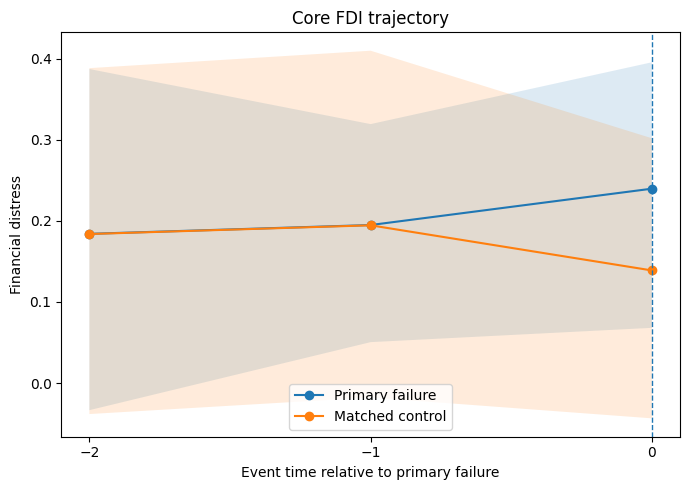

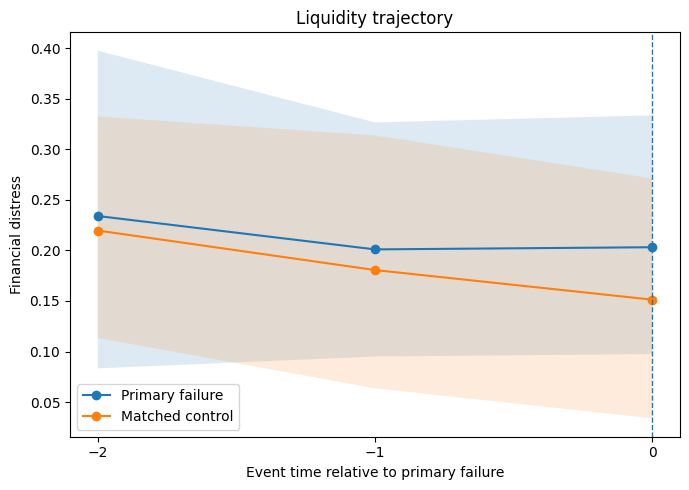

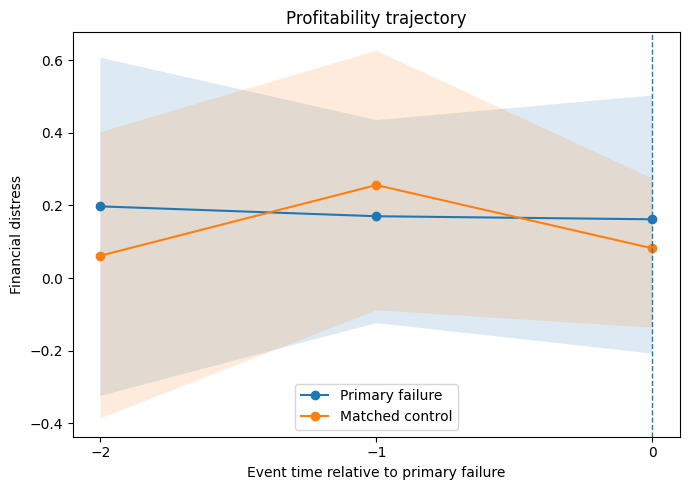

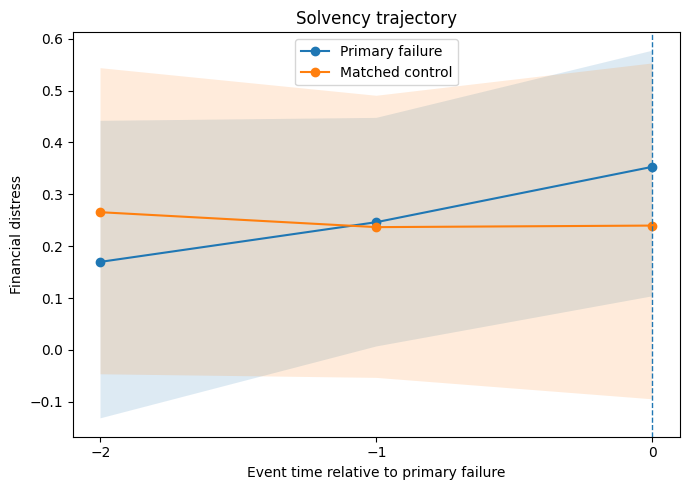

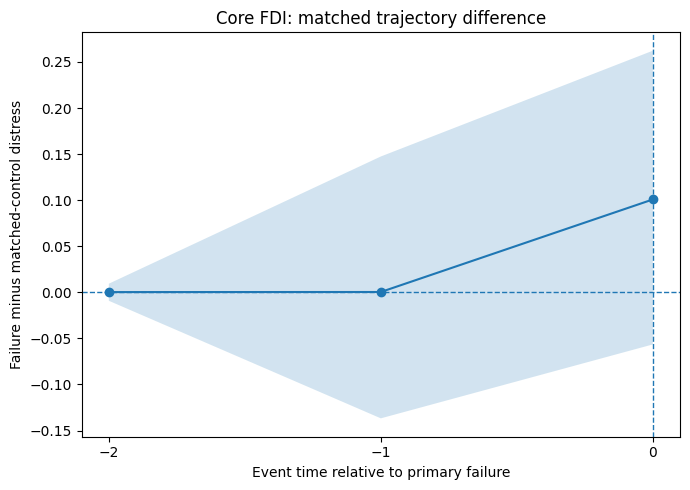

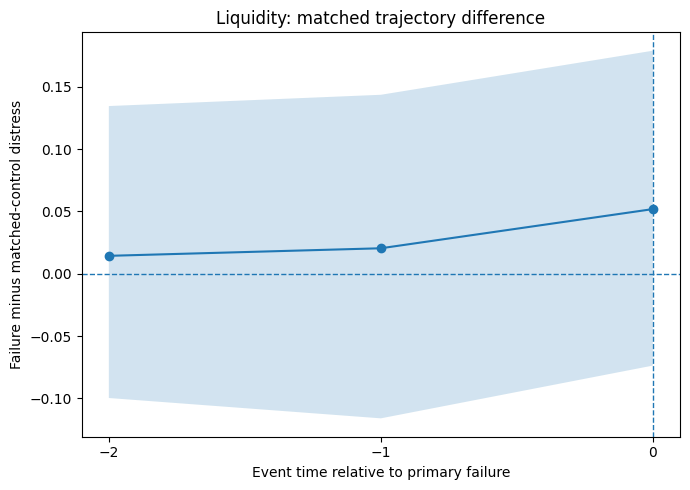

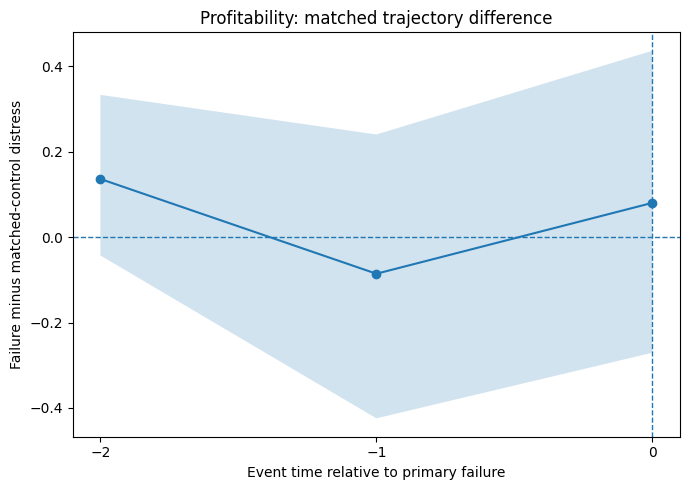

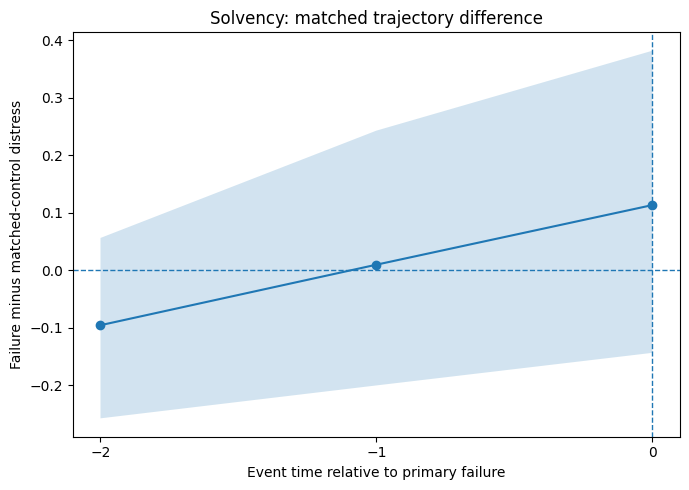

   Event time            Group  Expected matched observations  Firm-years observed  Firm-year observed (%)  Profitability available  Profitability (%)  Solvency available  Solvency (%)  Liquidity available  Liquidity (%)  Core FDI available  Core FDI (%)  Cash-flow capacity available  Cash-flow capacity (%)  Operating performance available  Operating performance (%)
0          -2  Primary failure                             26                   26                   100.0                       22               84.6                  26         100.0                   26          100.0                  26         100.0                             4                    15.4                                8                       30.8
1          -2  Matched control                             78                   78                   100.0                       66               84.6                  78         100.0                   75           96.2                  78         100.0        

In [ ]:
display(set_level_trajectories.head())
display(trajectory_summary)
display(trajectory_results)
display(matched_availability)
display(reporting_summary)
display(strict_size_balance)
print('Same-industry failure firms:',same_industry_matches['treated_id'].nunique())
display(same_industry_summary)
display(robustness_table)
display(robustness_near_failure)
display(core_composition)

plot_group_trajectories(trajectory_results)
plot_trajectory_differences(trajectory_results)

In [ ]:
with pd.ExcelWriter(RQ1_OUTPUT, engine='openpyxl') as writer:
    failures_by_year.to_excel(writer, sheet_name='failure_years',index=False)
    availability_table.to_excel(writer,sheet_name='availability', index=False)
    adjusted_availability.to_excel(writer, sheet_name='calendar_adjusted', index=False)
    joint_availability.to_excel(writer, sheet_name='joint_availability', index=False)
    matches.to_excel(writer, sheet_name='main_matches', index=False)
    balance_table.to_excel(writer, sheet_name='main_balance', index=False)
    matched_availability.to_excel(writer, sheet_name='matched_availability', index=False)
    trajectory_results.to_excel(writer, sheet_name='main_trajectories', index=False)
    set_level_trajectories.to_excel(writer, sheet_name='set_level', index=False)
    robustness_table.to_excel(writer, sheet_name='robustness', index=False)
    strict_size_balance.to_excel(writer, sheet_name='strict_size_balance', index=False)
    core_composition.to_excel(writer, sheet_name='core_composition', index=False)